[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter19_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 19: Review and Project Presentations

- Integrated case study on the BET index: stylised facts → GARCH(1,1)-t → VaR 1% → backtesting.
- Loss $L = -r$, daily log return in %; VaR is a positive number; the level is the tail probability (VaR 1%).

In [1]:
# On Colab, install arch first: !pip install arch
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

## Data

In [2]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# nume -> (simbol, eticheta, tip, data de start)
MARKETS = {
    'sp500':  ('GSPC.INDX',    'S&P 500',                  'index',  '2000-01-01'),
    'bet':    ('BET',          'BET',                      'index',  '2000-01-01'),
    'btc':    ('BTC-USD.CC',   'Bitcoin',                  'crypto', '2014-09-17'),
    'eurron': ('REF:EUR',      'EUR/RON (reference rate)', 'fx',     '2005-07-01'),
    'gold':   ('XAUUSD.FOREX', 'Gold (XAU/USD)',           'fx',     '2000-01-01'),
}
# active pentru portofolii (join pe preturi in zilele comune)
ASSETS = {
    'SPY': ('SPY.US', 'adjusted_close'), 'TLT': ('TLT.US', 'adjusted_close'), 'GLD': ('GLD.US', 'adjusted_close'),
    'BTC': ('BTC-USD.CC', 'close'),
    'TLV': ('TLV.RO', 'adjusted_close'), 'SNP': ('SNP.RO', 'adjusted_close'), 'BRD': ('BRD.RO', 'adjusted_close'),
    'TGN': ('TGN.RO', 'adjusted_close'), 'SNG': ('SNG.RO', 'adjusted_close'), 'SNN': ('SNN.RO', 'adjusted_close'),
    'EL': ('EL.RO', 'adjusted_close'), 'FP': ('FP.RO', 'adjusted_close'), 'TEL': ('TEL.RO', 'adjusted_close'),
}
LABELS = {k: v[1] for k, v in MARKETS.items()}

_CACHE = {}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Cursul oficial de referinta RON (arhive XML anuale BNR)."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END):
    """Pretul zilnic, curatat dupa conventiile capitolului."""
    symbol, _, kind, start0 = MARKETS[name]
    start = start or start0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    s = read_market(symbol)['close'].loc[start:end]
    s = s[s > 0].dropna()
    if kind != 'crypto':
        s = s[s.index.dayofweek < 5]          # fara cotatii de weekend
    if kind == 'index':
        s = s[s.diff() != 0]                  # fara sarbatori completate cu pretul anterior
    return s.rename(name)


def log_returns(name, start=None, end=END):
    """Randamente log pe calendarul propriu al seriei."""
    return np.log(load_close(name, start, end)).diff().dropna().rename(name)


def periods_per_year(r):
    """Frecventa reala: numarul mediu de observatii pe an calendaristic."""
    return len(r) / ((r.index[-1] - r.index[0]).days / 365.25)


def asset_price(key, end=END):
    symbol, col = ASSETS[key]
    s = read_market(symbol)[col].loc[:end]
    s = s[s > 0].dropna()
    if key != 'BTC':
        s = s[s.index.dayofweek < 5]
    return s.rename(key)


def joint_returns(keys, start=None, end=END):
    """Randamente log simple pentru mai multe active: join pe PRETURI in zilele comune, apoi randamente."""
    p = pd.concat([asset_price(k, end) for k in keys], axis=1, join='inner').dropna()
    if start:
        p = p.loc[start:]
    return np.log(p).diff().dropna()

## Case-study functions

- Stylised facts, GARCH(1,1)-t, rolling one-day VaR 1% (HS, Normal, GARCH-t, FHS), Kupiec and Christoffersen tests, Basel zones.

In [3]:
ALPHA = 0.01          # VaR 1%
ALPHA_ES = 0.025      # ES 2.5%
WINDOW = 1000         # zile in fereastra de estimare
REFIT = 21            # reestimare GARCH la fiecare 21 de zile
HS_WINDOW = 500       # fereastra pentru HS si pentru distributia Normala
MODELS = ['HS', 'Normal', 'GARCH-t', 'FHS']


# -----------------------------------------------------------------------------
# 1. FAPTE STILIZATE
# -----------------------------------------------------------------------------
def ljung_box(x, m=10):
    """Q(m) = T(T+2) sum rho_k^2/(T-k) si p-valoarea chi2(m)."""
    x = np.asarray(x) - np.mean(x)
    T = len(x)
    rho = np.array([np.sum(x[k:] * x[:-k]) for k in range(1, m + 1)]) / np.sum(x ** 2)
    q = T * (T + 2) * np.sum(rho ** 2 / (T - np.arange(1, m + 1)))
    return q, stats.chi2.sf(q, m)


def acf(x, nlags):
    x = np.asarray(x) - np.mean(x)
    d = np.sum(x ** 2)
    return np.array([np.sum(x[k:] * x[:-k]) / d for k in range(1, nlags + 1)])


def stylised_facts(r):
    """Rezumatul faptelor stilizate pentru randamentele r (in %)."""
    jb, jbp = stats.jarque_bera(r)
    q_r, q_rp = ljung_box(r)
    q_r2, q_r2p = ljung_box(r ** 2)
    z = (r - r.mean()) / r.std()
    return dict(N=len(r), start=str(r.index[0].date()), end=str(r.index[-1].date()),
                mean=r.mean(), sd=r.std(), skew=stats.skew(r), kurt=stats.kurtosis(r),
                min=r.min(), min_date=str(r.idxmin().date()), max=r.max(),
                jb=jb, jb_p=jbp, q_r=q_r, q_r_p=q_rp, q_r2=q_r2, q_r2_p=q_r2p,
                acf1_r=acf(r, 1)[0], acf1_abs=acf(np.abs(r), 1)[0],
                n4=int(np.sum(np.abs(z) > 4)), n4_normal=len(r) * 2 * stats.norm.sf(4))


def kurtosis_boot_ci(r, B=2000, block=20, seed=0):
    """CI 95% pentru excesul de kurtosis prin bootstrap pe blocuri mobile (pastreaza gruparea volatilitatii)."""
    rng = np.random.default_rng(seed)
    x = np.asarray(r)
    T = len(x)
    nb = int(np.ceil(T / block))
    ks = []
    for _ in range(B):
        idx = (rng.integers(0, T - block, nb)[:, None] + np.arange(block)).ravel()[:T]
        ks.append(stats.kurtosis(x[idx]))
    return np.percentile(ks, [2.5, 97.5])


# -----------------------------------------------------------------------------
# 2. GARCH(1,1)-t
# -----------------------------------------------------------------------------
def garch_t_fit(r, last_obs=None):
    am = arch_model(r, mean='Constant', vol='GARCH', p=1, q=1, dist='t', rescale=False)
    return am.fit(disp='off', last_obs=last_obs)


def garch_summary(res):
    """Parametri, erori standard robuste, persistenta si timpul de injumatatire."""
    p, se = res.params, res.std_err
    pers = p['alpha[1]'] + p['beta[1]']
    return dict(mu=p['mu'], omega=p['omega'], alpha=p['alpha[1]'], beta=p['beta[1]'], nu=p['nu'],
                se_alpha=se['alpha[1]'], se_beta=se['beta[1]'], se_nu=se['nu'],
                pers=pers, half_life=np.log(0.5) / np.log(pers),
                uncond_vol=np.sqrt(252 * p['omega'] / (1 - pers)))


def t_std_q(nu, a):
    """Cuantila de ordin a a distributiei Student-t standardizate (varianta 1)."""
    return stats.t.ppf(a, nu) * np.sqrt((nu - 2) / nu)


def t_std_es(nu, a):
    """E[Z | Z <= q_a] pentru Student-t standardizata (negativ)."""
    q = stats.t.ppf(a, nu)
    return -(stats.t.pdf(q, nu) / a) * (nu + q ** 2) / (nu - 1) * np.sqrt((nu - 2) / nu)


# -----------------------------------------------------------------------------
# 3. PROGNOZE VaR 1% PENTRU ZIUA URMATOARE (fereastra mobila)
# -----------------------------------------------------------------------------
def rolling_var(r, eval_from, window=WINDOW, refit=REFIT, a=ALPHA, a_es=ALPHA_ES):
    """Prognoze VaR (nivel a) si ES (nivel a_es) pentru fiecare zi t >= eval_from, cu informatia pana la t-1.
    Intoarce un DataFrame cu pierderea L_t si VaR/ES pentru HS, Normal, GARCH-t si FHS."""
    r = r.dropna()
    idx = r.index
    start = idx.searchsorted(pd.Timestamp(eval_from))
    start = max(start, window)
    rows = []
    for b0 in range(start, len(r), refit):
        b1 = min(b0 + refit, len(r))
        est = r.iloc[b0 - window:b0]
        am = arch_model(r.iloc[b0 - window:b1], mean='Constant', vol='GARCH', p=1, q=1, dist='t', rescale=False)
        res = am.fit(disp='off', last_obs=window)
        fx = am.fix(res.params)
        sig = fx.conditional_volatility          # sigma_t foloseste informatia pana la t-1
        mu = res.params['mu']
        nu = res.params['nu']
        z = ((est - mu) / sig.iloc[:window]).values   # reziduuri standardizate din fereastra
        zq = np.quantile(z, a)
        zes = z[z <= np.quantile(z, a_es)].mean()
        for j in range(b0, b1):
            hist = r.iloc[j - HS_WINDOW:j].values
            s = sig.iloc[j - (b0 - window)]
            L_hist = -hist
            q_hs = np.quantile(L_hist, 1 - a)
            q_hs_es = np.quantile(L_hist, 1 - a_es)
            m, sd = hist.mean(), hist.std(ddof=1)
            rows.append(dict(date=idx[j], r=r.iloc[j], L=-r.iloc[j], sigma=s,
                             HS=q_hs, HS_ES=L_hist[L_hist >= q_hs_es].mean(),
                             Normal=-(m + sd * stats.norm.ppf(a)),
                             Normal_ES=-(m - sd * stats.norm.pdf(stats.norm.ppf(a_es)) / a_es),
                             **{'GARCH-t': -(mu + s * t_std_q(nu, a)),
                                'GARCH-t_ES': -(mu + s * t_std_es(nu, a_es))},
                             FHS=-(mu + s * zq), FHS_ES=-(mu + s * zes)))
    return pd.DataFrame(rows).set_index('date')


# -----------------------------------------------------------------------------
# 4. BACKTESTING
# -----------------------------------------------------------------------------
def kupiec(hits, p=ALPHA):
    """Testul de acoperire (POF) al lui Kupiec: LR_uc ~ chi2(1)."""
    hits = np.asarray(hits, int)
    T, x = len(hits), int(hits.sum())
    ph = x / T
    ll0 = (T - x) * np.log(1 - p) + x * np.log(p)
    ll1 = (T - x) * np.log(1 - ph) + x * np.log(ph) if 0 < x < T else 0.0
    lr = -2 * (ll0 - ll1)
    return dict(T=T, x=x, rate=ph, LR=lr, p=stats.chi2.sf(lr, 1))


def christoffersen(hits, p=ALPHA):
    """Testul de independenta (lant Markov de ordinul 1) si testul combinat LR_cc = LR_uc + LR_ind."""
    h = np.asarray(hits, int)
    a, b = h[:-1], h[1:]
    n00, n01 = np.sum((a == 0) & (b == 0)), np.sum((a == 0) & (b == 1))
    n10, n11 = np.sum((a == 1) & (b == 0)), np.sum((a == 1) & (b == 1))

    def xlogy(n, q):
        return n * np.log(q) if n > 0 else 0.0
    pi01 = n01 / (n00 + n01)
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0.0
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)
    l1 = xlogy(n00, 1 - pi01) + xlogy(n01, pi01) + xlogy(n10, 1 - pi11) + xlogy(n11, pi11)
    l0 = xlogy(n00 + n10, 1 - pi) + xlogy(n01 + n11, pi)
    lr_ind = -2 * (l0 - l1)
    lr_uc = kupiec(h, p)['LR']
    return dict(n11=int(n11), pi01=pi01, pi11=pi11, LR_ind=lr_ind, p_ind=stats.chi2.sf(lr_ind, 1),
                LR_cc=lr_uc + lr_ind, p_cc=stats.chi2.sf(lr_uc + lr_ind, 2))


def traffic_light(x, T=250, p=ALPHA):
    """Zona Basel pentru x depasiri in T zile: verde (<5), galben (5-9), rosu (>=10) la T=250, p=1%."""
    cum = stats.binom.cdf(x, T, p)
    return 'green' if cum < 0.95 else ('yellow' if cum < 0.9999 else 'red')


def backtest_table(fc, models=MODELS, a=ALPHA):
    out = {}
    for m in models:
        hits = (fc['L'] > fc[m]).astype(int)
        k, c = kupiec(hits, a), christoffersen(hits, a)
        roll = hits.rolling(250).sum().dropna()
        zones = roll.apply(lambda x: traffic_light(int(x)))
        out[m] = dict(T=k['T'], x=k['x'], rate=k['rate'], LR_uc=k['LR'], p_uc=k['p'],
                      LR_ind=c['LR_ind'], p_ind=c['p_ind'], p_cc=c['p_cc'], n11=c['n11'],
                      share_red=float((zones == 'red').mean()), share_yellow=float((zones == 'yellow').mean()),
                      mean_var=float(fc[m].mean()))
    return out


def binom_band(T, p=ALPHA, level=0.95):
    """Intervalul binomial central pentru rata depasirilor, sub H0: rata = p."""
    lo, hi = stats.binom.ppf([(1 - level) / 2, 1 - (1 - level) / 2], T, p)
    return lo / T, hi / T

## Chart style and case-study steps

In [4]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Gray     = '#7F7F7F'   # doar linii de referinta, benzi, grila
Teal     = '#17A2B8'
MODEL_COL = {'HS': MainBlue, 'Normal': Orange, 'GARCH-t': Forest, 'FHS': IDAred}

import tempfile
HERE = tempfile.gettempdir()   # intermediate tables (forecast CSV) go to a temporary folder
CHART_DIR = '.'
EVAL_FROM = '2005-01-01'


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent."""
    os.makedirs(CHART_DIR, exist_ok=True)
    plt.savefig(os.path.join(CHART_DIR, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(CHART_DIR, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, axes, ncol=3):
    """O singura legenda sub o figura cu mai multe panouri."""
    h, l = [], []
    for ax in axes:
        for hh, ll in zip(*ax.get_legend_handles_labels()):
            if ll not in l:
                h.append(hh)
                l.append(ll)
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=ncol, frameon=False)


# =============================================================================
# DATE: randamente log zilnice ale BET, in %
# =============================================================================
r = 100 * log_returns('bet')
RES = {}


# =============================================================================
# 1. FAPTE STILIZATE
# =============================================================================
def part_facts():
    sf = stylised_facts(r)
    lo, hi = kurtosis_boot_ci(r)
    sf['kurt_ci'] = [lo, hi]
    sf['ppy'] = len(r) / ((r.index[-1] - r.index[0]).days / 365.25)
    sf['ann_vol'] = r.std() * np.sqrt(sf['ppy'])
    RES['facts'] = sf

    z = np.sort(((r - r.mean()) / r.std()).values)
    p = (np.arange(1, len(z) + 1) - 0.5) / len(z)
    zn = stats.norm.ppf(p)
    lags = np.arange(1, 51)
    a_r, a_abs = acf(r.values, 50), acf(np.abs(r.values), 50)
    band = 1.96 / np.sqrt(len(r))
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4))
    ax = axes[0]
    ax.scatter(zn, z, s=4, color=MainBlue, label='BET standardised daily log returns')
    ax.plot([-5, 5], [-5, 5], color=Gray, lw=0.8, ls='--', label='Normal distribution (45-degree line)')
    ax.set_xlabel('Normal quantile')
    ax.set_ylabel('Empirical quantile')
    ax.set_title('Quantile-quantile plot', fontsize=9, loc='left')
    ax = axes[1]
    ax.bar(lags - 0.2, a_r, width=0.4, color=MainBlue, label='ACF of returns $r_t$')
    ax.bar(lags + 0.2, a_abs, width=0.4, color=IDAred, label='ACF of absolute returns $|r_t|$')
    ax.axhspan(-band, band, color=Gray, alpha=0.25, lw=0, label='95% band under i.i.d.')
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xlabel('Lag (trading days)')
    ax.set_ylabel('Autocorrelation')
    ax.set_title('Autocorrelation function', fontsize=9, loc='left')
    fig.tight_layout()
    fig_legend_bottom(fig, axes, ncol=2)
    save_fig('ch19_bet_facts')


# =============================================================================
# 2. GARCH(1,1)-t PE TOATA SELECTIA
# =============================================================================
def part_garch():
    res = garch_t_fit(r)
    g = garch_summary(res)
    RES['garch'] = g
    sig = res.conditional_volatility
    fig, ax = plt.subplots(figsize=(9.6, 3.2))
    ax.plot(r.index, r.values, color=MainBlue, lw=0.4, label='BET daily log return (%)')
    ax.plot(sig.index, 2 * sig.values, color=IDAred, lw=0.7, label=r'$\pm 2\hat\sigma_t$, GARCH(1,1)-t')
    ax.plot(sig.index, -2 * sig.values, color=IDAred, lw=0.7)
    ax.axhline(0, color=Gray, lw=0.4)
    ax.set_xlim(r.index[0], r.index[-1])
    ax.set_ylabel('%')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch19_bet_garch')
    s = sig.copy()
    RES['garch']['sigma_last'] = float(s.iloc[-1])
    RES['garch']['sigma_max'] = float(s.max())
    RES['garch']['sigma_max_date'] = str(s.idxmax().date())
    return res


# =============================================================================
# 3-4. VaR 1% PENTRU ZIUA URMATOARE SI BACKTESTING
# =============================================================================
def part_var(full_res):
    fc = rolling_var(r, EVAL_FROM)
    fc.to_csv(os.path.join(HERE, 'ch19_forecasts_bet.csv'))
    bt = backtest_table(fc)
    RES['backtest'] = bt
    RES['eval'] = dict(start=str(fc.index[0].date()), end=str(fc.index[-1].date()), T=len(fc))
    lo, hi = binom_band(len(fc))
    RES['eval']['band'] = [lo, hi]
    RES['es'] = {m: float(fc[m + '_ES'].mean()) for m in MODELS}

    # grafic: pierderi si VaR 1% (2020-2026)
    d = fc.loc['2020-01-01':]
    fig, ax = plt.subplots(figsize=(9.6, 3.3))
    ax.bar(d.index, d['L'].clip(lower=0), width=1.5, color=Teal, alpha=0.7, label='Daily loss (gains set to 0)')
    ax.plot(d.index, d['Normal'], color=Orange, lw=0.9, label='Normal VaR 1% (500 days)')
    ax.plot(d.index, d['FHS'], color=IDAred, lw=0.9, label='FHS VaR 1% (GARCH-t filter)')
    exc = d['L'] > d['FHS']
    ax.scatter(d.index[exc], d['L'][exc], s=12, color='black', zorder=3, label='Loss above FHS VaR 1%')
    ax.set_ylabel('Loss (% of position)')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch19_bet_var')
    RES['var_2020'] = dict(n=len(d), x_fhs=int(exc.sum()), x_normal=int((d['L'] > d['Normal']).sum()),
                          fhs_max=float(d['FHS'].max()), fhs_max_date=str(d['FHS'].idxmax().date()),
                          fhs_last=float(fc['FHS'].iloc[-1]), normal_last=float(fc['Normal'].iloc[-1]))

    # grafic: ratele depasirilor
    fig, ax = plt.subplots(figsize=(7.6, 3.2))
    x = np.arange(len(MODELS))
    rates = [100 * bt[m]['rate'] for m in MODELS]
    ax.bar(x, rates, width=0.55, color=[MODEL_COL[m] for m in MODELS])
    ax.axhspan(100 * lo, 100 * hi, color=Gray, alpha=0.25, lw=0, label='95% binomial band if the rate is 1%')
    ax.axhline(1.0, color='black', lw=0.8, ls='--', label='Target: 1%')
    for i, v in enumerate(rates):
        ax.text(i, v + 0.04, f'{v:.2f}%', ha='center', va='bottom', fontsize=8, color='black')
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS)
    ax.set_ylabel('Share of days with loss > VaR 1% (%)')
    legend_outside_bottom(ax, ncol=2, y=-0.16)
    save_fig('ch19_breach_rates')

    # grafic: depasiri pe 250 de zile si zonele Basel
    fig, ax = plt.subplots(figsize=(9.6, 3.3))
    ax.axhspan(-0.5, 4.5, color=Forest, alpha=0.08, lw=0, label='Green zone (0-4)')
    ax.axhspan(4.5, 9.5, color=Amber, alpha=0.15, lw=0, label='Yellow zone (5-9)')
    top = 0
    for m in MODELS:
        roll = (fc['L'] > fc[m]).astype(int).rolling(250).sum()
        top = max(top, roll.max())
        ax.plot(roll.index, roll.values, color=MODEL_COL[m], lw=0.9, label=m)
    ax.axhspan(9.5, top + 2, color=IDAred, alpha=0.08, lw=0, label='Red zone (10+)')
    ax.set_ylim(-0.5, top + 2)
    ax.set_xlim(fc.index[0], fc.index[-1])
    ax.set_ylabel('Breaches in the last 250 days')
    legend_outside_bottom(ax, ncol=4, y=-0.14)
    save_fig('ch19_rolling_breaches')

    # capcana: informatie din viitor (parametri estimati pe toata selectia)
    p = full_res.params
    sig_full = full_res.conditional_volatility.loc[fc.index]
    var_full = -(p['mu'] + sig_full * t_std_q(p['nu'], ALPHA))
    hs_full = np.quantile(fc['L'], 1 - ALPHA)
    k_full = kupiec((fc['L'] > var_full).astype(int))
    k_hsfull = kupiec((fc['L'] > hs_full).astype(int))
    RES['lookahead'] = dict(garch_full_rate=k_full['rate'], garch_full_p=k_full['p'], garch_full_x=k_full['x'],
                            hs_full_rate=k_hsfull['rate'], hs_full_x=k_hsfull['x'], hs_full_var=float(hs_full))
    fig, ax = plt.subplots(figsize=(7.6, 3.0))
    lab = ['HS', 'GARCH-t']
    oos = [100 * bt['HS']['rate'], 100 * bt['GARCH-t']['rate']]
    ins = [100 * k_hsfull['rate'], 100 * k_full['rate']]
    x = np.arange(2)
    ax.bar(x - 0.18, oos, 0.34, color=MainBlue, label='Rolling estimation (only past data)')
    ax.bar(x + 0.18, ins, 0.34, color=Amber, label='Parameters from the full sample (look-ahead)')
    ax.axhline(1.0, color='black', lw=0.8, ls='--', label='Target: 1%')
    for i in range(2):
        ax.text(i - 0.18, oos[i] + 0.03, f'{oos[i]:.2f}%', ha='center', va='bottom', fontsize=8, color='black')
        ax.text(i + 0.18, ins[i] + 0.03, f'{ins[i]:.2f}%', ha='center', va='bottom', fontsize=8, color='black')
    ax.set_xticks(x)
    ax.set_xticklabels(lab)
    ax.set_ylabel('Breach rate of VaR 1% (%)')
    legend_outside_bottom(ax, ncol=3, y=-0.12)
    save_fig('ch19_lookahead')


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()


def fmt_p(p):
    return '<0.001' if p < 0.001 else f'{p:.3f}'


## Step 1. Stylised facts of the BET

- Moments, Jarque–Bera, Ljung–Box on $r_t$ and $r_t^2$, a block-bootstrap CI for the kurtosis.

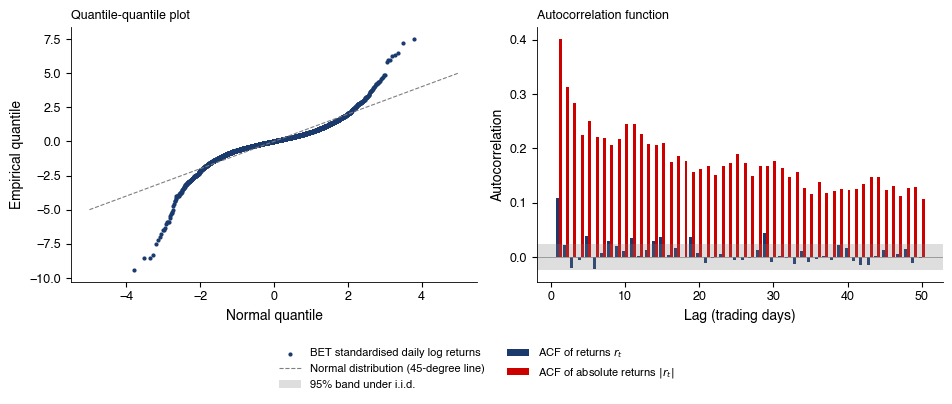

,BET
N,6670
start,2000-01-06
end,2026-09-18
mean,0.063931
sd,1.398639
skew,-0.653293
kurt,11.062947
min,-13.116763
min_date,2009-01-07
max,10.564512


In [5]:
part_facts()
pd.Series({k: v for k, v in RES['facts'].items() if not isinstance(v, list)}).to_frame('BET')

## Step 2. GARCH(1,1) with Student-t innovations

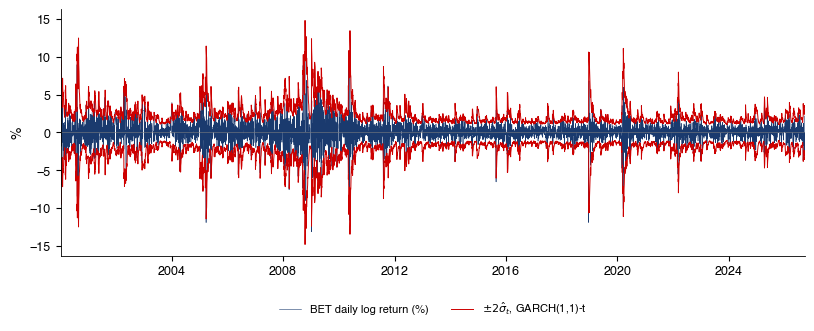

mu             0.0832
omega          0.0448
alpha          0.1916
beta           0.7991
nu             5.0112
se_alpha       0.0246
se_beta        0.0237
se_nu          0.3084
pers           0.9907
half_life     74.2777
uncond_vol    34.8567
sigma_last     1.6697
sigma_max      7.3946
dtype: float64

In [6]:
full = part_garch()
pd.Series({k: v for k, v in RES['garch'].items() if not isinstance(v, str)}).round(4)

## Steps 3–4. One-day VaR 1% and backtesting, 2005–2026

- Forecast for day $t$ uses data up to $t-1$; GARCH re-estimated every 21 days on the last 1000 days.

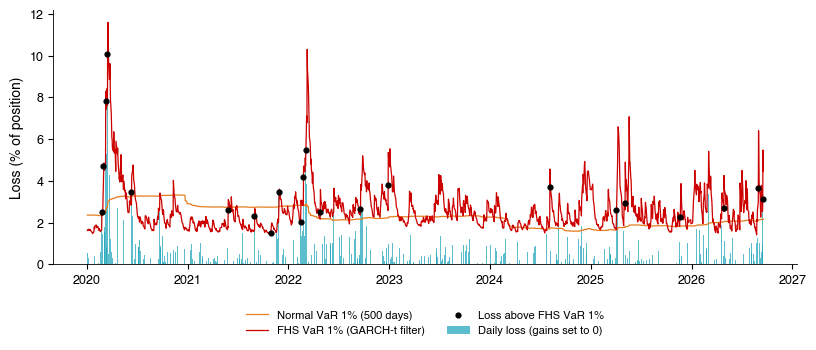

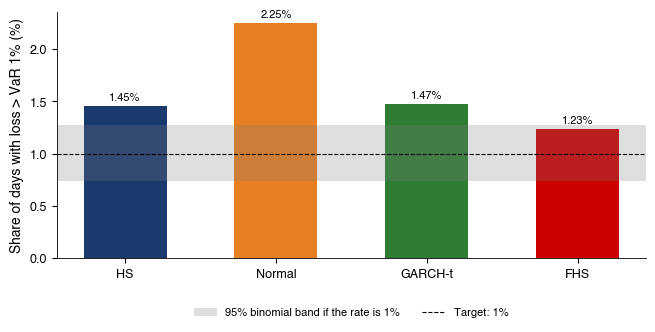

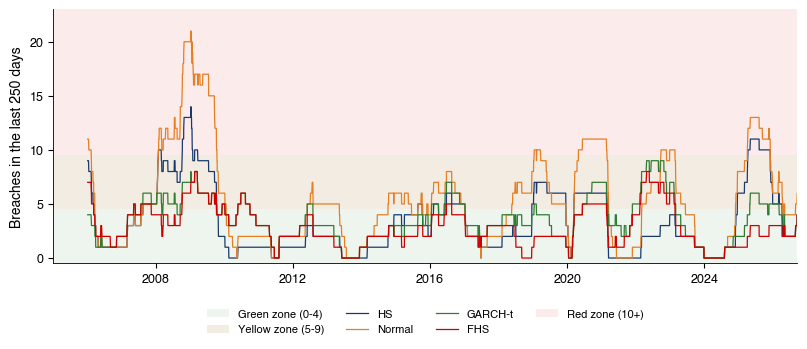

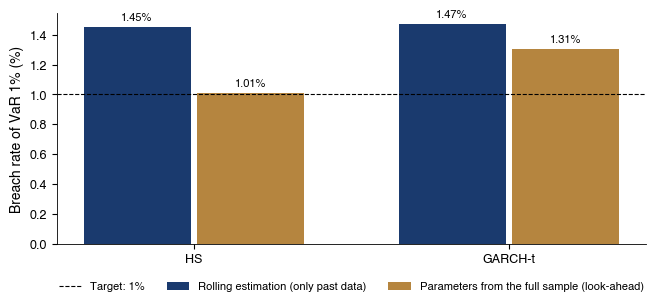

,x,rate,p_uc,p_ind,p_cc,share_red,mean_var
HS,79.0,0.0145,0.0016,0.0000,0.0000,0.0546,3.6638
Normal,122.0,0.0225,0.0000,0.0000,0.0000,0.1862,2.9039
GARCH-t,80.0,0.0147,0.0011,0.8641,0.0047,0.0000,2.9512
FHS,67.0,0.0123,0.0953,0.2674,0.1345,0.0000,3.1704


In [7]:
part_var(full)
bt = pd.DataFrame(RES['backtest']).T
bt[['x', 'rate', 'p_uc', 'p_ind', 'p_cc', 'share_red', 'mean_var']].astype(float).round(4)

## The look-ahead trap

- Parameters estimated on the full sample give breach rates that no forecaster could have achieved in real time.

In [8]:
pd.Series(RES['lookahead']).round(4)

garch_full_rate     0.0131
garch_full_p        0.0299
garch_full_x       71.0000
hs_full_rate        0.0101
hs_full_x          55.0000
hs_full_var         4.2436
dtype: float64

## Your turn

- Replace `'bet'` with another series from `MARKETS` (for example `'sp500'` or `'btc'`) and rerun the four steps.
- Which model passes both backtests on your series?